In [148]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt

%config InlineBackend.figure_formats = ['svg']

In [149]:
ket0 = qt.basis(3, 0)
bra0 = qt.basis(3, 0).dag()

ket1 = qt.basis(3, 1)
bra1 = qt.basis(3, 1).dag()

ket2 = qt.basis(3, 2)
bra2 = qt.basis(3, 2).dag()

# 2 The model

## 2.1 Free evolution

Throughout this simulation, $\hbar=1$

In [150]:
omega = 2*np.pi*4.985
Delta_2 = -2*np.pi*0.3071
H = omega*ket1*bra1 + (2*omega+Delta_2)*ket2*bra2

psi0 = (ket0 + ket1 + ket2).unit()
options = {'store_states': True, 'atol': 1e-10, 'rtol': 1e-10}

times = np.linspace(0, 1, 1000)
result = qt.sesolve(H, psi0, times, e_ops=[ket0*bra0, ket1*bra1, ket2*bra2], options=options)

We find the amplitudes

In [151]:
def find_amplitudes(result, times):
    """
    Extract complex-defined wavefunction amplitudes
    """
    amplitudes = []
    for idx in range(len(times)):
        amplitudes.append([bra0*result.states[idx], bra1*result.states[idx], bra2*result.states[idx]])
    amplitudes = np.array(amplitudes)

    return amplitudes

In [152]:
amplitudes = find_amplitudes(result, times)

amplitudes

array([[ 0.57735027+0.j        ,  0.57735027+0.j        ,
         0.57735027+0.j        ],
       [ 0.57735027+0.j        ,  0.57706652-0.01809872j,
         0.57628436-0.03506662j],
       [ 0.57735027+0.j        ,  0.57621556-0.03617964j,
         0.57309058-0.07000375j],
       ...,
       [ 0.57735031+0.j        ,  0.57025352+0.09024576j,
        -0.35798967+0.45296428j],
       [ 0.57735031+0.j        ,  0.57280228+0.07232515j,
        -0.32981698+0.47387129j],
       [ 0.57735031+0.j        ,  0.57478801+0.05433346j,
        -0.30042647+0.49302857j]])

### Analytical expression for this case: No drive

In [153]:
amp_th_free = []

for t in times:
    amp_th_free.append([np.sqrt(1/3), np.sqrt(1/3)*np.exp(-1j*omega*t), np.sqrt(1/3)*np.exp(-1j*(2*omega+Delta_2)*t)])

amp_th_free = np.array(amp_th_free)

We now compare between the two cases

In [154]:
fig, axes = plt.subplots(nrows=3, figsize=(12, 6), sharex=True)

axes[0].plot(times, np.round(result.expect[0], 3), label=r'Pop $|0\rangle$', color='tab:blue')
axes[0].plot(times, np.round(result.expect[1], 3), label=r'Pop $|1\rangle$', color='tab:orange')
axes[0].plot(times, np.round(result.expect[2], 3), label=r'Pop $|2\rangle$', color='tab:green')

axes[1].plot(times, np.round(np.real(amplitudes[:, 0]), 3), label=r'$\text{Re}[c_0(t)]$', color='tab:blue')
axes[1].scatter(times[::10], np.round(np.real(amp_th_free[:, 0][::10]), 3), label=r'$\text{Re}[c_0(t)] (th)$', color='tab:blue', s=5, marker='x')
axes[1].plot(times, np.round(np.real(amplitudes[:, 1]), 3), label=r'$\text{Re}[c_1(t)]$', color='tab:orange')
axes[1].scatter(times[::10], np.round(np.real(amp_th_free[:, 1])[::10], 3), label=r'$\text{Re}[c_1(t)] (th)$', color='tab:orange', s=5, marker='x')
axes[1].plot(times, np.round(np.real(amplitudes[:, 2]), 3), label=r'$\text{Re}[c_2(t)]$', color='tab:green')
axes[1].scatter(times[::10], np.round(np.real(amp_th_free[:, 2][::10]), 3), label=r'$\text{Re}[c_2(t)] (th)$', color='tab:green', s=5, marker='x')

axes[2].plot(times, np.round(np.imag(amplitudes[:, 0]), 3), label=r'$\text{Imag}[c_0(t)]$', color='tab:blue')
axes[2].plot(times, np.round(np.imag(amplitudes[:, 1]), 3), label=r'$\text{Imag}[c_1(t)]$', color='tab:orange')
axes[2].plot(times, np.round(np.imag(amplitudes[:, 2]), 3), label=r'$\text{Imag}[c_2(t)]$', color='tab:green')

axes[0].legend(loc='upper right', fontsize=17)
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=17)
    ax.set_xlim([min(times), max(times)])

axes[2].set_xlabel(r'$t$ (ns)', fontsize=17)

fig.tight_layout()
# fig.savefig('./fig1.eps', dpi=600, bbox_inches='tight')
plt.close()

This is Figure 1 in the Note.

## 2.2 We now introduce the drive

In [155]:
Omega_0_01 = 0.0971537581604938
Omega_0_12 = 0.25681015

In [156]:
def delta_func(subspace):
    if subspace == '01':
        return 0
    if subspace == '12':
        return -Delta_2
    
def lambda_0_func(on):
    if on == True:
        return 0.54
    else:
        return 0

def lambda_1_func(on):
    if on == True:
        return 0.61
    else:
        return 0.0

# 3 De-coupled subspaces

## 3.1 Square pulse/de-coupled

In [157]:
lambda_0 = lambda_0_func(True)
lambda_1 = lambda_1_func(False)

tg = 60

def Omega(t):
    if t < tg:
        return Omega_0_01
    else:
        return 0

H0 = Delta_2*ket2*bra2
H1 = (lambda_0/2)*(ket0*bra1+ket1*bra0)

H= [H0, [H1, lambda t: Omega(t)]]

H

[Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=True
 Qobj data =
 [[ 0.          0.          0.        ]
  [ 0.          0.          0.        ]
  [ 0.          0.         -1.92956621]],
 [Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=True
  Qobj data =
  [[0.   0.27 0.  ]
   [0.27 0.   0.  ]
   [0.   0.   0.  ]],
  <function __main__.<lambda>(t)>]]

In [158]:
psi0 = (ket0+ 1j*ket1 + ket2).unit()
options = {'store_states': True, 'atol': 1e-10, 'rtol': 1e-10}

times = np.linspace(0, tg*2, 1000)
result = qt.sesolve(H, psi0, times, e_ops=[ket0*bra0, ket1*bra1, ket2*bra2], options=options)

In [159]:
amplitudes = find_amplitudes(result, times)

amplitudes

array([[0.57735027+0.j        , 0.        +0.57735027j,
        0.57735027+0.j        ],
       [0.57916659+0.j        , 0.        +0.57552821j,
        0.56191141+0.13262314j],
       [0.58097716+0.j        , 0.        +0.57370045j,
        0.51642054+0.25815336j],
       ...,
       [0.57556095+0.j        , 0.        -0.57913422j,
        0.10184308-0.56829669j],
       [0.57556095+0.j        , 0.        -0.57913422j,
        0.22966315-0.52970556j],
       [0.57556095+0.j        , 0.        -0.57913422j,
        0.34520043-0.46278484j]])

### Analytical expression for this case: Drive on, decoupled subspaces

In [160]:
def ampth_c2_decoupled_square(t):
    return (1/np.sqrt(3))*np.exp(-1j*Delta_2*t)

def ampth_c0_decoupled_square(t, tg):
    if t < tg:
        return (1/np.sqrt(3))*(np.cos(lambda_0*Omega_0_01*t/2)+np.sin(lambda_0*Omega_0_01*t/2))
    else:
        return (1/np.sqrt(3))*(np.cos(lambda_0*Omega_0_01*tg/2)+np.sin(lambda_0*Omega_0_01*tg/2))

def ampth_c1_decoupled_square(t, tg):
    if t < tg:
        return (1j/np.sqrt(3))*(np.cos(lambda_0*Omega_0_01*t/2)-np.sin(lambda_0*Omega_0_01*t/2))
    else:
        return (1j/np.sqrt(3))*(np.cos(lambda_0*Omega_0_01*tg/2)-np.sin(lambda_0*Omega_0_01*tg/2))

In [161]:
ampth_decoupled_square = []
for t in times:
    ampth_decoupled_square.append([ampth_c0_decoupled_square(t, tg), ampth_c1_decoupled_square(t, tg), ampth_c2_decoupled_square(t)])
ampth_decoupled_square = np.array(ampth_decoupled_square)

In [162]:
fig, axes = plt.subplots(nrows=3, figsize=(12, 6), sharex=True)

axes[0].plot(times, result.expect[0], label=r'Pop $|0\rangle$', color='tab:blue')
axes[0].scatter(times[::10], np.abs(ampth_decoupled_square[:, 0][::10])**2, color='tab:blue', s=5, marker='x')
axes[0].plot(times, result.expect[1], label=r'Pop $|1\rangle$', color='tab:orange')
axes[0].scatter(times[::10], np.abs(ampth_decoupled_square[:, 1][::10])**2, color='tab:orange', s=5, marker='x')
axes[0].plot(times, result.expect[2], label=r'Pop $|2\rangle$', color='tab:green')
axes[0].scatter(times[::10], np.abs(ampth_decoupled_square[:, 2][::10])**2, color='tab:green', s=5, marker='x')
axes[0].legend(loc='right', fontsize=17)
# axes[0].set_ylim(1/3-0.01, 1/3+0.01)

axes[1].plot(times, np.round(np.real(amplitudes[:, 0]), 3), label=r'$\text{Re}[c_0(t)]$', color='tab:blue')
axes[1].scatter(times[::10], np.round(np.real(ampth_decoupled_square[:, 0][::10]), 3), label=r'$\text{Re}[c_0(t)] (th)$', color='tab:blue', s=5, marker='x')
axes[1].plot(times, np.round(np.real(amplitudes[:, 1]), 3), label=r'$\text{Re}[c_1(t)]$', color='tab:orange')
axes[1].scatter(times[::10], np.round(np.real(ampth_decoupled_square[:, 1][::10]), 3), label=r'$\text{Re}[c_1(t)] (th)$', color='tab:orange', s=5, marker='x')
axes[1].plot(times, np.round(np.real(amplitudes[:, 2]), 3), label=r'$\text{Re}[c_2(t)]$', color='tab:green')
axes[1].scatter(times[::10], np.round(np.real(ampth_decoupled_square[:, 2][::10]), 3), label=r'$\text{Re}[c_2(t)] (th)$', color='tab:green', s=5, marker='x')

axes[2].plot(times, np.round(np.imag(amplitudes[:, 0]), 3), label=r'$\text{Imag}[c_0(t)]$', color='tab:blue')
axes[2].plot(times, np.round(np.imag(amplitudes[:, 1]), 3), label=r'$\text{Imag}[c_1(t)]$', color='tab:orange')
axes[2].plot(times, np.round(np.imag(amplitudes[:, 2]), 3), label=r'$\text{Imag}[c_2(t)]$', color='tab:green')

for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=17)
    ax.set_xlim(min(times), max(times))

axes[2].set_xlabel(r'$t$ (ns)', fontsize=17)

fig.tight_layout()
# fig.savefig('./figures/pa_note/fig2.eps', dpi=600, bbox_inches='tight')
plt.close()

This is Figure 2 in the Note.

## 3.2 Gaussian drive

In [163]:
def constant_drive(t, omega_d):
    if t < tg:
        return Omega_0_01*np.cos(omega_d*t)
    else:
        return 0
    
def add_pulse(pulse_train, pulse_name, start, tg, sigma, A):
    """
    Add a pulse to the pulse train.
    """
    pulse_train[pulse_name] = {'start': start, 'tg': tg, 'sigma': sigma, 'A': A}
    pulse_train['clock'] = pulse_train['clock']+tg

def Omega(t, args):
    for item, pulse_specs in args.items():
        if item == 'clock':
            continue
        if t <= pulse_specs['start'] or t >= (pulse_specs['start'] + pulse_specs['tg']):
            continue
        else:
            t_local = t
            t_local += -pulse_specs['start'] # convert to local time of a pulse
            return pulse_specs['A'] * (np.exp(-(t_local-pulse_specs['tg']/2)**2/(2*pulse_specs['sigma']**2)) - np.exp(-pulse_specs['tg']**2/(8*pulse_specs['sigma']**2))) \
                / (1-np.exp(-pulse_specs['tg']**2/(8*pulse_specs['sigma']**2)))
    return 0

def pulse(t, omega_d, phase, args):
    return Omega(t, args)*np.cos(omega_d*t + phase)

def pulse_envelope(t, args):
    return Omega(t,args)

In [164]:
pulse_train = {'clock': 0}
add_pulse(pulse_train, pulse_name='pulse_1', start=pulse_train['clock'], tg=60, sigma=60/4, A=0.18151219398122395)

pulse_train

{'clock': 60,
 'pulse_1': {'start': 0, 'tg': 60, 'sigma': 15.0, 'A': 0.18151219398122395}}

In [165]:
(Delta_2/(0.61*0.18151219398122395))

-17.427056673998187

In [166]:
times = np.linspace(-20, 80, 10000)

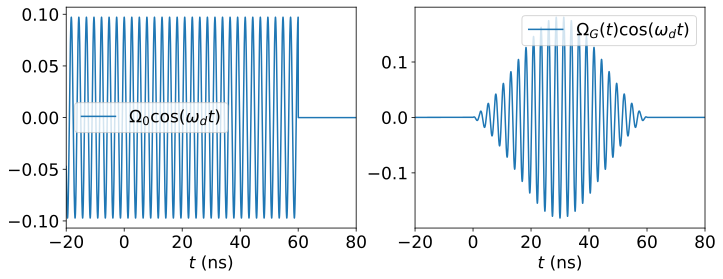

In [168]:
fig, axes = plt.subplots(ncols=2, figsize=(10,4))

axes[0].plot(times, [constant_drive(t, omega_d=omega/13) for t in times],label=r'$\Omega_0\cos(\omega_d t)$')
axes[1].plot(times, [pulse(t, omega_d=omega/13, phase=0, args=pulse_train) for t in times],label=r'$\Omega_G(t)\cos(\omega_d t)$')

for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=17)
    ax.set_xlim([min(times), max(times)])
    ax.set_xlabel(r'$t$ (ns)', fontsize=17)
    ax.legend(fontsize=17)

fig.tight_layout()

# fig.savefig('./fig3.eps', dpi=600, bbox_inches='tight')
# plt.close()

This is Figure 3 in the Note.

We could try to integrate these two drives with respect to time.

In [62]:
area1 = Omega_0_01*60*lambda_0

print('Area square pulse: ', area1)

Area square pulse:  3.1477817643999995


In [63]:
from scipy.integrate import quad

def gaussian_for_integration(t):
    return Omega(t, args)

args = pulse_train
area, error = quad(gaussian_for_integration, 0, 100)  # Integrate over the time range

print(f"Numerically calculated area under the Gaussian curve: {area*lambda_0:.10f}")

Numerically calculated area under the Gaussian curve: 3.1477817644


### Using Gaussian drive

In [64]:
pulse_train = {'clock': 0}
add_pulse(pulse_train, pulse_name='pulse_1', start=pulse_train['clock'], tg=60, sigma=60/4, A=0.18151219398122395)

pulse_train

{'clock': 60,
 'pulse_1': {'start': 0, 'tg': 60, 'sigma': 15.0, 'A': 0.18151219398122395}}

In [65]:
H0 = Delta_2*ket2*bra2
H1 = (lambda_0/2)*(ket0*bra1+ket1*bra0)

times = np.linspace(0, tg*2, 1000)

H= [H0, [H1, lambda t, args: Omega(t, args)]]

result = qt.sesolve(H, psi0, times, e_ops=[ket0*bra0, ket1*bra1, ket2*bra2], args=pulse_train, options=options)

In [66]:
amplitudes = find_amplitudes(result, times)

amplitudes

array([[0.57735027+0.j        , 0.        +0.57735027j,
        0.57735027+0.j        ],
       [0.57735455+0.j        , 0.        +0.57734599j,
        0.56191141+0.13262314j],
       [0.57736745+0.j        , 0.        +0.57733309j,
        0.51642054+0.25815336j],
       ...,
       [0.57556099+0.j        , 0.        -0.57913427j,
        0.10184318-0.56829658j],
       [0.57556099+0.j        , 0.        -0.57913427j,
        0.22966322-0.52970543j],
       [0.57556099+0.j        , 0.        -0.57913427j,
        0.34520047-0.46278469j]])

For this section we compare the difference between a square pulse and a Gaussian pulse. In both cases the subspaces were decoupled.

In [67]:
fig, axes = plt.subplots(nrows=2, figsize=(9, 5), sharex=True)

axes[0].plot(times, result.expect[0], label=r'Pop $|0\rangle$', color='tab:blue')
axes[0].plot(times[::10], np.abs(ampth_decoupled_square[:, 0][::10])**2, color='tab:blue', linestyle='dashed')
axes[0].plot(times, result.expect[1], label=r'Pop $|1\rangle$', color='tab:orange')
axes[0].plot(times[::10], np.abs(ampth_decoupled_square[:, 1][::10])**2, color='tab:orange', linestyle='dashed')
axes[0].plot(times, result.expect[2], label=r'Pop $|2\rangle$', color='tab:green')
axes[0].plot(times[::10], np.abs(ampth_decoupled_square[:, 2][::10])**2, color='tab:green', linestyle='dashed')
# axes[0].set_ylim(1/3-0.38, 1/3+0.38)
# axes[0].set_ylim(1/3-0.01, 1/3+0.01)
axes[0].legend(loc='right', fontsize=12)

axes[1].plot(times, np.round(np.real(amplitudes[:, 0]), 3), color='tab:blue', label=r'$Re[c_0(t)]$ de-coupled/Gaussian')
axes[1].plot(times[::10], np.round(np.real(ampth_decoupled_square[:, 0][::10]), 3), color='tab:blue', linestyle='dashed', label=r'$Re[c_0(t)]$ de-coupled/square')
axes[1].plot(times, np.round(np.real(amplitudes[:, 1]), 3), label=r'$\text{Re}[c_1(t)]$ de-coupled/Gaussian', color='tab:orange')
axes[1].plot(times[::10], np.round(np.real(ampth_decoupled_square[:, 1][::10]), 3), label=r'$\text{Re}[c_1(t)]$ de-coupled/square', color='tab:orange', linestyle='dashed')

axes[1].plot(times, np.round(np.imag(amplitudes[:, 0]), 3), label=r'$\text{Imag}[c_0(t)]$', color='tab:blue')
axes[1].plot(times[::10], np.round(np.imag(ampth_decoupled_square[:, 0][::10]), 3), label=r'$\text{Re}[c_0(t)] (th)$', color='tab:blue', linestyle='dashed')
axes[1].plot(times, np.round(np.imag(amplitudes[:, 1]), 3), label=r'$\text{Imag}[c_1(t)]$', color='tab:orange')
axes[1].plot(times[::10], np.round(np.imag(ampth_decoupled_square[:, 1][::10]), 3), label=r'$\text{Re}[c_0(t)] (th)$', color='tab:orange', linestyle='dashed')
axes[1].set_ylim(-1, 1)
# axes[3].plot(times, np.abs(np.round(np.real(amplitudes[:, 2]), 5)-np.round(np.real(amp_th[:, 2]), 5)), label='Theory - Simulation')
# axes[3].legend()

for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=17)
    ax.set_xlim(min(times), max(times))

axes[1].set_xlabel(r'$t$ (ns)', fontsize=17)

fig.tight_layout()
# fig.savefig('./figures/pa_note/fig4.eps', dpi=600, bbox_inches='tight')
plt.close()

In [68]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, axes = plt.subplots(nrows=3, figsize=(9, 6), sharex=True)

axes[0].plot(times, np.round(np.real(amplitudes[:, 2]), 3), color='tab:blue', label=r'$Re[c_0(t)]$ de-coupled/Gaussian')
axes[0].plot(times, np.round(np.real(ampth_decoupled_square[:, 2]), 3), color='tab:blue', linestyle='dashed', label=r'$Re[c_0(t)]$ de-coupled/square')
axes[1].plot(times, np.round(np.imag(amplitudes[:, 2]), 3), label=r'$\\text{Re}[c_1(t)]$ de-coupled/Gaussian', color='tab:orange')
axes[1].plot(times, np.round(np.imag(ampth_decoupled_square[:, 2]), 3), label=r'$\\text{Re}[c_1(t)]$ de-coupled/square', color='tab:orange', linestyle='dashed')
ax_inset1 = inset_axes(axes[0], width="90%", height="30%", loc="upper right")
ax_inset1.plot(times, np.round(np.real(amplitudes[:, 2]), 3), color='tab:blue')
ax_inset1.set_xlim([min(times), max(times)])
ax_inset1.tick_params(axis='both', which='major', labelsize=8)

ax_inset2 = inset_axes(axes[1], width="90%", height="30%", loc="upper right")
ax_inset2.plot(times, np.round(np.imag(amplitudes[:, 2]), 3), color='tab:orange')
ax_inset2.set_xlim([min(times), max(times)])
ax_inset2.tick_params(axis='both', which='major', labelsize=8)

# Adjust ticks and labels for the main plot
for ax in [axes[0], axes[1]]:
    ax.tick_params(axis='both', which='major', labelsize=17)
    ax.set_xlim([0, 25])
    ax.set_ylim([-0.7, 1.7])

# Final adjustments
axes[2].set_xlabel(r'$t$ (ns)', fontsize=17)
axes[2].plot(times, np.abs(np.real(amplitudes[:, 2])-np.real(ampth_decoupled_square[:, 2])))
axes[2].set_ylim([0, 0.7e-7])

fig.tight_layout()
# fig.savefig('./figures/pa_note/fig5.eps', dpi=600, bbox_inches='tight')
plt.close()

/var/folders/z6/rm3bbyf1499dhyn1b2tcy4s80000gn/T/ipykernel_23308/4148813957.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


# 4 Full interaction picture

We now venture into the regime where interesting things are supposed to happen

In [69]:
lambda_0 = lambda_0_func(True)
lambda_1 = lambda_1_func(True)

lambda_0, lambda_1

(0.54, 0.61)

## 4.1 Square pulse

In [70]:
H0 = Delta_2*ket2*bra2
H1 = (lambda_0/2)*(ket0*bra1+ket1*bra0)
H2 = (lambda_1/2)*(ket1*bra2+ket2*bra1)

tg = 60
times = np.linspace(0, tg*2, 1000)

def SquarePulse(t):
    if t < tg:
        return Omega_0_01
    else:
        return 0

H= [H0, [H1, lambda t: SquarePulse(t)], [H2, lambda t: SquarePulse(t)]]

result = qt.sesolve(H, psi0, times, e_ops=[ket0*bra0, ket1*bra1, ket2*bra2], args=pulse_train, options=options)

We compare to the case of decoupled square pulses.

In [71]:
amplitudes = find_amplitudes(result, times)

amplitudes

array([[5.77350269e-01+0.00000000e+00j, 0.00000000e+00+5.77350269e-01j,
        5.77350269e-01+0.00000000e+00j],
       [5.79163365e-01-2.49687537e-07j, 2.37371790e-04+5.73487922e-01j,
        5.63941236e-01+1.32859420e-01j],
       [5.80964414e-01-1.98322245e-06j, 9.37905300e-04+5.69721767e-01j,
        5.20358307e-01+2.59082631e-01j],
       ...,
       [5.75330090e-01-1.16626631e-02j, 5.05147158e-03-5.82822528e-01j,
        1.15852287e-01-5.61898479e-01j],
       [5.75330090e-01-1.16626631e-02j, 5.05147159e-03-5.82822528e-01j,
        2.41828005e-01-5.20260386e-01j],
       [5.75330091e-01-1.16626631e-02j, 5.05147159e-03-5.82822528e-01j,
        3.54870334e-01-4.50797847e-01j]])

In [72]:
fig, axes = plt.subplots(nrows=2, figsize=(9, 5), sharex=True)

axes[0].plot(times, result.expect[0], label=r'Pop $|0\rangle$', color='tab:blue')
axes[0].plot(times[::10], np.abs(ampth_decoupled_square[:, 0][::10])**2, color='tab:blue', linestyle='dashed')
axes[0].plot(times, result.expect[1], label=r'Pop $|1\rangle$', color='tab:orange')
axes[0].plot(times[::10], np.abs(ampth_decoupled_square[:, 1][::10])**2, color='tab:orange', linestyle='dashed')
axes[0].plot(times, result.expect[2], label=r'Pop $|2\rangle$', color='tab:green')
axes[0].plot(times[::10], np.abs(ampth_decoupled_square[:, 2][::10])**2, color='tab:green', linestyle='dashed')
# axes[0].set_ylim(1/3-0.38, 1/3+0.38)
# axes[0].set_ylim(1/3-0.02, 1/3+0.02)
axes[0].legend(loc='right', fontsize=12)

axes[1].plot(times, np.round(np.real(amplitudes[:, 0]), 3), color='tab:blue', label=r'$Re[c_0(t)]$ de-coupled/Gaussian')
axes[1].plot(times[::10], np.round(np.real(ampth_decoupled_square[:, 0][::10]), 3), color='tab:blue', linestyle='dashed', label=r'$Re[c_0(t)]$ de-coupled/square')
axes[1].plot(times, np.round(np.real(amplitudes[:, 1]), 3), label=r'$\text{Re}[c_1(t)]$ de-coupled/Gaussian', color='tab:orange')
axes[1].plot(times[::10], np.round(np.real(ampth_decoupled_square[:, 1][::10]), 3), label=r'$\text{Re}[c_1(t)]$ de-coupled/square', color='tab:orange', linestyle='dashed')

axes[1].plot(times, np.round(np.imag(amplitudes[:, 0]), 3), label=r'$\text{Imag}[c_0(t)]$', color='tab:blue')
axes[1].plot(times[::10], np.round(np.imag(ampth_decoupled_square[:, 0][::10]), 3), label=r'$\text{Re}[c_0(t)] (th)$', color='tab:blue', linestyle='dashed')
axes[1].plot(times, np.round(np.imag(amplitudes[:, 1]), 3), label=r'$\text{Imag}[c_1(t)]$', color='tab:orange')
axes[1].plot(times[::10], np.round(np.imag(ampth_decoupled_square[:, 1][::10]), 3), label=r'$\text{Re}[c_0(t)] (th)$', color='tab:orange', linestyle='dashed')
axes[1].set_ylim(-1, 1)

for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=17)
    ax.set_xlim(min(times), max(times))

axes[1].set_xlabel(r'$t$ (ns)', fontsize=17)

fig.tight_layout()
# fig.savefig('./figures/pa_note/fig6.eps', dpi=600, bbox_inches='tight')
plt.close()

This is Figure 6 in the Note.

We make the guess.

In [73]:
result.expect[2].shape

(1000,)

In [74]:
result.expect[2][-100]

0.3291516887484181

In [75]:
np.abs(ampth_decoupled_square.T[2][-1])**2

0.3333333333333334

In [76]:
result.expect[2][-1] - np.abs(ampth_decoupled_square[:, 2][::100][-1])**2

-0.004181680838636459

In [77]:
def delta(t, theta, epsilon):
    return (-2/np.sqrt(3))*np.sin(theta/2)*np.sin(Delta_2*t+theta/2)+epsilon*np.cos(Delta_2*t+theta)

In [78]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, axes = plt.subplots(nrows=3, figsize=(9, 6))

axes[0].plot(times, np.round(np.real(amplitudes[:, 2]), 3), color='tab:blue', label=r'$Re[c_0(t)]$ de-coupled/Gaussian')
axes[0].plot(times, np.round(np.real(ampth_decoupled_square[:, 2]), 3), color='tab:blue', linestyle='dashed', label=r'$Re[c_0(t)]$ de-coupled/square')
axes[1].plot(times, np.round(np.imag(amplitudes[:, 2]), 3), label=r'$\\text{Re}[c_1(t)]$ de-coupled/Gaussian', color='tab:orange')
axes[1].plot(times, np.round(np.imag(ampth_decoupled_square[:, 2]), 3), label=r'$\\text{Re}[c_1(t)]$ de-coupled/square', color='tab:orange', linestyle='dashed')

ax_inset1 = inset_axes(axes[0], width="90%", height="30%", loc="upper right")
ax_inset1.plot(times, np.round(np.real(amplitudes[:, 2]), 3), color='tab:blue')
ax_inset1.set_xlim([min(times), max(times)])
ax_inset1.tick_params(axis='both', which='major', labelsize=8)

ax_inset2 = inset_axes(axes[1], width="90%", height="30%", loc="upper right")
ax_inset2.plot(times, np.round(np.imag(amplitudes[:, 2]), 3), color='tab:orange')
ax_inset2.set_xlim([min(times), max(times)])
ax_inset2.tick_params(axis='both', which='major', labelsize=8)

# Adjust ticks and labels for the main plot
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=17)
    ax.set_xlim([0, 25])
    ax.set_ylim([-0.7, 1.8])

# Final adjustments
axes[2].set_xlabel(r'$t$ (ns)', fontsize=17)
axes[2].plot(times, np.real(amplitudes[:, 2])-np.real(ampth_decoupled_square[:, 2]), color='tab:green', alpha=0.9)
# axes[2].plot(times, [delta(t, -0.0275, 0.00676648) for t in times])
axes[2].set_ylim([-0.025, 0.025])
axes[2].set_xlim([tg-40, tg+40])
axes[2].axvline(tg, color='black', linestyle='--', label='End of interaction')
# axes[2].axhline(0.0185, color='grey', linestyle='--')
axes[2].legend(fontsize=12)

fig.tight_layout()
# fig.savefig('./figures/pa_note/fig7.eps', dpi=600, bbox_inches='tight')
plt.close()

/var/folders/z6/rm3bbyf1499dhyn1b2tcy4s80000gn/T/ipykernel_23308/1572162441.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


In [79]:
fig, ax = plt.subplots(figsize=(9, 3))

# 0.0067664827962296 from Wolfram Alpha

ax.tick_params(axis='both', which='major', labelsize=17)
ax.set_xlabel(r'$t$ (ns)', fontsize=17)
ax.plot(times, np.real(amplitudes[:, 2])-np.real(ampth_decoupled_square[:, 2]), color='tab:green', alpha=0.9)
ax.plot(times, [delta(t, -0.029, 0.0067664827962296) for t in times])
ax.set_ylim([-0.025, 0.025])
ax.set_xlim([tg-40, tg+40])
ax.axvline(tg, color='black', linestyle='--', label='End of interaction')
ax.legend(fontsize=12)

fig.tight_layout()
# fig.savefig('./figures/pa_note/fig8.eps', dpi=600, bbox_inches='tight')
plt.close()

### Eigenvalue problem

In [80]:
def cubic_eqn(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d

a = 1
b = -Delta_2
c = -(Omega_0_01**2/4)*(lambda_0**2+lambda_1**2)
d = lambda_0**2*Omega_0_01**2*(Delta_2)/4

x_range = np.linspace(-5, 5, 10000)
y_range = [cubic_eqn(x, a, b, c, d) for x in x_range]

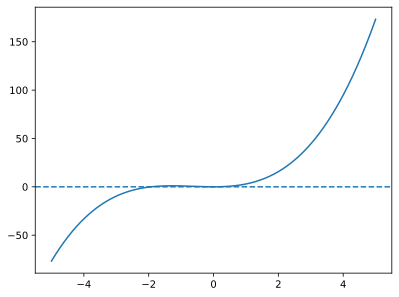

In [81]:
plt.plot(x_range, y_range)
plt.axhline(0, linestyle='dashed')
# plt.close()

In [82]:
a, b, c, d

(1, 1.9295662078348508, -0.0015661416383471278, -0.0013277197727319596)

In [83]:
xi_0 = b**2 - 3*a*c 
xi_1 = 2*b**3 - 9*a*b*c + 27*a**2*d 

xi_0, xi_1

(3.7279241753332077, 14.359770516269474)

In [84]:
cuberoots_of_1 = 1, complex(-.5, .75**.5), complex(-.5, -.75**.5)

def cuberoot(z):
    cuberoot = complex(z)**(1/3)
    return [cuberoot * cr1 for cr1 in cuberoots_of_1]

In [85]:
import cmath

C = cuberoot((xi_1 + cmath.sqrt(xi_1**2-4*xi_0**3))/2)

C

[(1.9302487481240866+0.04543066914105397j),
 (-1.0044684876491219+1.6489291169280422j),
 (-0.9257802604749649-1.6943597860690962j)]

In [86]:
Eks = [np.real((-1/3)*(-Delta_2+C[k]+xi_0/C[k])) for k in range(3)]

Eks.sort()

In [87]:
Eks

[-1.9300212346943413, -0.02600189562830694, 0.02645692248779774]

In [88]:
### Quick comparision with QuTiP diagonalization

H0 = Delta_2*ket2*bra2
H1 = (Omega_0_01*lambda_0/2)*(ket0*bra1+ket1*bra0)
H2 = (Omega_0_01*lambda_1/2)*(ket1*bra2+ket2*bra1)

H_test = H0 + H1 + H2

eig_vals, eig_vecs = H_test.eigenstates()

eig_vals

array([-1.93002123, -0.0260019 ,  0.02645692])

(-0.05, 0.05)

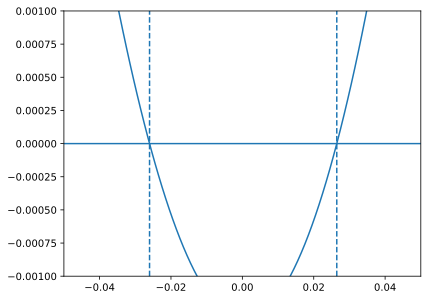

In [89]:
plt.plot(x_range, y_range)
plt.axhline(0)
plt.axvline(np.real(Eks[0]), linestyle='dashed')
plt.axvline(np.real(Eks[1]), linestyle='dashed')
plt.axvline(np.real(Eks[2]), linestyle='dashed')
plt.ylim([-0.001, 0.001])
plt.xlim([-0.05, 0.05])

In [90]:
A = lambda_0*Omega_0_01/2
B = lambda_1*Omega_0_01/2

def N_k(k):
    return np.sqrt(1+np.abs(A/Eks[k])**2+np.abs(np.abs(B/(Delta_2-Eks[k])))**2)

N_k(0), N_k(1), N_k(2)

(65.1288814106015, 1.420556939756605, 1.4082835203027348)

In [91]:
def phi_k(k):
    return (1/N_k(k))*((A/Eks[k])*ket0+ket1+(-B/(Delta_2-Eks[k]))*ket2)

In [92]:
phi_k(0), phi_k(1), phi_k(2)

(Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
 Qobj data =
 [[-2.08683284e-04]
  [ 1.53541713e-02]
  [-9.99882096e-01]],
 Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
 Qobj data =
 [[-0.71016573]
  [ 0.70394926]
  [ 0.01095805]],
 Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
 Qobj data =
 [[0.70403451]
  [0.71008429]
  [0.0107571 ]])

In [93]:
psi0 = (1/np.sqrt(3))*(ket0+1j*ket1+ket2)

c_k = [phi_k(k).dag()*psi0 for k in range(3)]

c_k

[(-0.5774026806263222+0.008864734917674272j),
 (-0.4036877439406771+0.40642529210307315j),
 (0.41268512992874185+0.40996735448946703j)]

In [94]:
def a_k(t, k):
    if k == 0:
        brak = bra0
    elif k == 1:
        brak = bra1 
    elif k == 2:
        brak = bra2
    if t < tg: 
        return c_k[0]*np.exp(-1j*Eks[0]*t)*brak*phi_k(0) + c_k[1]*np.exp(-1j*Eks[1]*t)*brak*phi_k(1) + c_k[2]*np.exp(-1j*Eks[2]*t)*brak*phi_k(2)
    else:
        return c_k[0]*np.exp(-1j*Eks[0]*tg)*brak*phi_k(0) + c_k[1]*np.exp(-1j*Eks[1]*tg)*brak*phi_k(1) + c_k[2]*np.exp(-1j*Eks[2]*tg)*brak*phi_k(2)

In [95]:
fig, axes = plt.subplots(nrows=2, figsize=(9, 5), sharex=True)

axes[0].plot(times, result.expect[0], label=r'Pop $|0\rangle$', color='tab:blue')
axes[0].scatter(times[::25], [np.abs(a_k(t, 0))**2 for t in times[::25]], color='tab:blue', s=5)
axes[0].plot(times, result.expect[1], label=r'Pop $|1\rangle$', color='tab:orange')
axes[0].scatter(times[::25], [np.abs(a_k(t, 1))**2 for t in times[::25]], color='tab:orange', s=5)
axes[0].plot(times, result.expect[2], label=r'Pop $|2\rangle$', color='tab:green')
axes[0].scatter(times[::25], [np.abs(a_k(t, 2))**2 for t in times[::25]], color='tab:green', s=5)
# axes[0].set_ylim(1/3-0.38, 1/3+0.38)
# axes[0].set_ylim(1/3-0.02, 1/3+0.02)
axes[0].legend(loc='upper right', fontsize=12)

axes[1].plot(times, np.round(np.real(amplitudes[:, 0]), 3), color='tab:blue', label=r'$Re[c_0(t)]$ de-coupled/Gaussian')
axes[1].scatter(times[::25], [np.real(a_k(t, 0)) for t in times[::25]], color='tab:blue', s=5, label=r'$Re[c_0(t)]$ de-coupled/square')
axes[1].plot(times, np.round(np.real(amplitudes[:, 1]), 3), label=r'$\text{Re}[c_1(t)]$ de-coupled/Gaussian', color='tab:orange')
axes[1].scatter(times[::25], [np.real(a_k(t, 1)) for t in times[::25]], label=r'$\text{Re}[c_1(t)]$ de-coupled/square', color='tab:orange', s=5)

axes[1].plot(times, np.round(np.imag(amplitudes[:, 0]), 3), color='tab:blue', label=r'$Imag[c_1(t)]$ de-coupled/Gaussian')
axes[1].scatter(times[::25], [np.imag(a_k(t, 0)) for t in times[::25]], color='tab:blue', s=5, label=r'$Imag[c_1(t)]$ de-coupled/square')
axes[1].plot(times, np.round(np.imag(amplitudes[:, 1]), 3), label=r'$\text{Imag}[c_1(t)]$ de-coupled/Gaussian', color='tab:orange')
axes[1].scatter(times[::25], [np.imag(a_k(t, 1)) for t in times[::25]], label=r'$\text{Imag}[c_1(t)]$ de-coupled/square', color='tab:orange', s=5)
axes[1].set_ylim(-1, 1)

for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=17)
    ax.set_xlim(min(times), max(times))
axes[1].set_xlim([tg-25, tg+5])
axes[1].set_xlabel(r'$t$ (ns)', fontsize=17)

fig.tight_layout()
# fig.savefig('./fig9.eps', dpi=600, bbox_inches='tight')
plt.close()

In [96]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, axes = plt.subplots(nrows=3, figsize=(9, 6))

axes[0].plot(times, np.round(np.real(amplitudes[:, 2]), 3), color='tab:blue', label=r'$Re[c_0(t)]$ de-coupled/Gaussian')
axes[0].scatter(times[::100], [np.real(a_k(t, 2)) for t in times[::100]], color='tab:blue', label=r'$Re[c_0(t)]$ de-coupled/square', s=10, marker='x')
axes[1].plot(times, np.round(np.imag(amplitudes[:, 2]), 3), label=r'$\\text{Re}[c_1(t)]$ de-coupled/Gaussian', color='tab:orange')
axes[1].scatter(times[::100], [np.imag(a_k(t, 2)) for t in times[::100]], color='tab:orange', label=r'$Re[c_0(t)]$ de-coupled/square', s=10, marker='x')

ax_inset1 = inset_axes(axes[0], width="90%", height="30%", loc="upper right")
ax_inset1.plot(times, np.round(np.real(amplitudes[:, 2]), 3), color='tab:blue')
ax_inset1.set_xlim([min(times), max(times)])
ax_inset1.tick_params(axis='both', which='major', labelsize=8)

ax_inset2 = inset_axes(axes[1], width="90%", height="30%", loc="upper right")
ax_inset2.plot(times, np.round(np.imag(amplitudes[:, 2]), 3), color='tab:orange')
ax_inset2.set_xlim([min(times), max(times)])
ax_inset2.tick_params(axis='both', which='major', labelsize=8)

for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=17)
    ax.set_xlim([0, 25])
    ax.set_ylim([-0.7, 1.8])
    
times2 = np.linspace(0, tg, 10000)

axes[2].set_xlabel(r'$t$ (ns)', fontsize=17)
axes[2].plot(times, np.real(amplitudes[:, 2])-np.real(ampth_decoupled_square[:, 2]), color='tab:green', alpha=0.9)
axes[2].scatter(times2[::50], [np.real(a_k(t, 2)) for t in times2[::50]]-np.real([ampth_c2_decoupled_square(t) for t in times2[::50]]), color='tab:green', s=5, marker='x')
axes[2].set_ylim([-0.04, 0.04])
axes[2].set_xlim([tg-50, tg+20])
axes[2].axvline(tg, color='black', linestyle='--', label='End of interaction')
# axes[2].axhline(0.0185, color='grey', linestyle='--')
axes[2].legend(fontsize=12)

fig.tight_layout()
# fig.savefig('./figures/pa_note/fig10.eps', dpi=600, bbox_inches='tight')
plt.close()

/var/folders/z6/rm3bbyf1499dhyn1b2tcy4s80000gn/T/ipykernel_23308/1566676909.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


In [97]:
amplitudes[:, 2][np.argmin(np.abs(times - tg))]

(-0.4866156749832358+0.30218723646732604j)

In [98]:
a_2_naught = 0

for k in range(3):
    a_2_naught += c_k[k]*np.exp(-1j*Eks[k]*tg)*bra2*phi_k(k)

a_2_naught

(-0.519328261085486+0.24382404801344132j)

In [99]:
def a_2(t, offset):
    return a_2_naught*np.exp(-1j*Delta_2*t-1j*offset)

In [100]:
def wf_2_sq(t, offset):
    if t < tg:
        return a_k(t, 2)
    else:
        t = t - tg
        return a_2(t, offset)

In [101]:
times_spec1 = np.linspace(0, tg, 10000)
times_spec2 = np.linspace(0, max(times)-tg, 10000)
times_spec3 = np.linspace(tg, max(times), 10000)

In [102]:
fig, axes = plt.subplots(ncols=2, figsize=(9, 3), gridspec_kw={'width_ratios': [1, 1]}, sharey=True)

axes[0].set_xlabel(r'$t$ (ns)', fontsize=17)
axes[0].axvline(tg, color='black', linestyle='--', label='End of interaction')
axes[0].plot(times, np.real(amplitudes[:, 2])-np.real(ampth_decoupled_square[:, 2]), color='gray', alpha=0.9)
axes[0].scatter(times[::500], np.real([wf_2_sq(t,offset=0) for t in times[::500]])-np.real([ampth_c2_decoupled_square(t) for t in times[::500]]), color='tab:green', s=5, marker='x')
axes[0].set_xlim([min(times), max(times)-110])
axes[0].legend(fontsize=12)

axes[1].set_xlabel(r'$t$ (ns)', fontsize=17)
axes[1].plot(times, np.real(amplitudes[:, 2])-np.real(ampth_decoupled_square[:, 2]), color='gray', alpha=0.9)
axes[1].scatter(times[::100], np.real([wf_2_sq(t,offset=0) for t in times[::100]])-np.real([ampth_c2_decoupled_square(t) for t in times[::100]]), color='tab:green', s=5, marker='x')
axes[1].set_xlim([tg-5, tg+15])
axes[1].axvline(tg, color='black', linestyle='--')

for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=12)
fig.tight_layout()
# fig.savefig('./figures/pa_note/fig11.eps', dpi=600, bbox_inches='tight')
plt.close()

## Gaussian pulse

In [103]:
# The two subspaces are coupled

lambda_0, lambda_1

(0.54, 0.61)

In [129]:
pulse_train = {'clock': 0}
# add_pulse(pulse_train, pulse_name='pulse_1', start=pulse_train['clock'], tg=60, sigma=60/4, A=0.18151219398122395)
add_pulse(pulse_train, pulse_name='pulse_2', start=pulse_train['clock'], tg=20, sigma=20/4, A=1)

In [130]:
pulse_train

{'clock': 20, 'pulse_2': {'start': 0, 'tg': 20, 'sigma': 5.0, 'A': 1}}

In [125]:
H0 = Delta_2*ket2*bra2
H1 = (lambda_0/2)*(ket0*bra1+ket1*bra0)
H2 = (lambda_1/2)*(ket1*bra2+ket2*bra1)

times = np.linspace(0, tg*2, 1000)

H= [H0, [H1, lambda t, args: Omega(t, args)], [H2, lambda t, args: Omega(t, args)]]

result = qt.sesolve(H, psi0, times, e_ops=[ket0*bra0, ket1*bra1, ket2*bra2], args=pulse_train, options=options)

In [106]:
amplitudes = find_amplitudes(result, times)

amplitudes

array([[ 5.77350269e-01+0.00000000e+00j,  0.00000000e+00+5.77350269e-01j,
         5.77350269e-01+0.00000000e+00j],
       [ 5.77354546e-01-2.20550236e-12j,  7.42937038e-07+5.77341225e-01j,
         5.61916222e-01+1.32623514e-01j],
       [ 5.77367446e-01-7.03758398e-11j,  5.87436634e-06+5.77314720e-01j,
         5.16439599e-01+2.58156323e-01j],
       ...,
       [ 5.75900473e-01-2.83701900e-03j, -2.98430771e-03-5.79119993e-01j,
         1.23184667e-01-5.63708491e-01j],
       [ 5.75900473e-01-2.83701900e-03j, -2.98430771e-03-5.79119993e-01j,
         2.49380088e-01-5.20337675e-01j],
       [ 5.75900473e-01-2.83701900e-03j, -2.98430771e-03-5.79119993e-01j,
         3.62238222e-01-4.49138281e-01j]])

In [107]:
ampth_decoupled_square = []
for t in times:
    ampth_decoupled_square.append([ampth_c0_decoupled_square(t, tg), ampth_c1_decoupled_square(t, tg), ampth_c2_decoupled_square(t)])
ampth_decoupled_square = np.array(ampth_decoupled_square)

In [108]:
fig, axes = plt.subplots(nrows=2, figsize=(9, 5), sharex=True)

axes[0].plot(times, result.expect[0], label=r'Pop $|0\rangle$', color='tab:blue')
axes[0].plot(times[::10], np.abs(ampth_decoupled_square[:, 0][::10])**2, color='tab:blue', linestyle='dashed')
axes[0].plot(times, result.expect[1], label=r'Pop $|1\rangle$', color='tab:orange')
axes[0].plot(times[::10], np.abs(ampth_decoupled_square[:, 1][::10])**2, color='tab:orange', linestyle='dashed')
axes[0].plot(times, result.expect[2], label=r'Pop $|2\rangle$', color='tab:green')
axes[0].plot(times[::10], np.abs(ampth_decoupled_square[:, 2][::10])**2, color='tab:green', linestyle='dashed')
# axes[0].set_ylim(1/3-0.38, 1/3+0.38)
# axes[0].set_ylim(1/3-0.01, 1/3+0.01)
axes[0].legend(loc='right', fontsize=12)

axes[1].plot(times, np.round(np.real(amplitudes[:, 0]), 3), color='tab:blue', label=r'$Re[c_0(t)]$ de-coupled/Gaussian')
axes[1].plot(times[::10], np.round(np.real(ampth_decoupled_square[:, 0][::10]), 3), color='tab:blue', linestyle='dashed', label=r'$Re[c_0(t)]$ de-coupled/square')
axes[1].plot(times, np.round(np.real(amplitudes[:, 1]), 3), label=r'$\text{Re}[c_1(t)]$ de-coupled/Gaussian', color='tab:orange')
axes[1].plot(times[::10], np.round(np.real(ampth_decoupled_square[:, 1][::10]), 3), label=r'$\text{Re}[c_1(t)]$ de-coupled/square', color='tab:orange', linestyle='dashed')

axes[1].plot(times, np.round(np.imag(amplitudes[:, 0]), 3), label=r'$\text{Imag}[c_0(t)]$', color='tab:blue')
axes[1].plot(times[::10], np.round(np.imag(ampth_decoupled_square[:, 0][::10]), 3), label=r'$\text{Re}[c_0(t)] (th)$', color='tab:blue', linestyle='dashed')
axes[1].plot(times, np.round(np.imag(amplitudes[:, 1]), 3), label=r'$\text{Imag}[c_1(t)]$', color='tab:orange')
axes[1].plot(times[::10], np.round(np.imag(ampth_decoupled_square[:, 1][::10]), 3), label=r'$\text{Re}[c_0(t)] (th)$', color='tab:orange', linestyle='dashed')
axes[1].set_ylim(-1, 1)
# axes[3].plot(times, np.abs(np.round(np.real(amplitudes[:, 2]), 5)-np.round(np.real(amp_th[:, 2]), 5)), label='Theory - Simulation')
# axes[3].legend()

for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=17)
    ax.set_xlim(min(times), max(times))

axes[1].set_xlabel(r'$t$ (ns)', fontsize=17)

fig.tight_layout()
# fig.savefig('./figures/pa_note/fig12.eps', dpi=600, bbox_inches='tight')
plt.close()

In [109]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, axes = plt.subplots(nrows=3, figsize=(9, 6))

axes[0].plot(times, np.round(np.real(amplitudes[:, 2]), 3), color='tab:blue', label=r'$Re[c_0(t)]$ de-coupled/Gaussian')
axes[0].plot(times, np.round(np.real(ampth_decoupled_square[:, 2]), 3), color='tab:blue', linestyle='dashed', label=r'$Re[c_0(t)]$ de-coupled/square')
axes[1].plot(times, np.round(np.imag(amplitudes[:, 2]), 3), label=r'$\\text{Re}[c_1(t)]$ de-coupled/Gaussian', color='tab:orange')
axes[1].plot(times, np.round(np.imag(ampth_decoupled_square[:, 2]), 3), label=r'$\\text{Re}[c_1(t)]$ de-coupled/square', color='tab:orange', linestyle='dashed')
ax_inset1 = inset_axes(axes[0], width="90%", height="30%", loc="upper right")
ax_inset1.plot(times, np.round(np.real(amplitudes[:, 2]), 3), color='tab:blue')
ax_inset1.set_xlim([min(times), max(times)])
ax_inset1.tick_params(axis='both', which='major', labelsize=8)

ax_inset2 = inset_axes(axes[1], width="90%", height="30%", loc="upper right")
ax_inset2.plot(times, np.round(np.imag(amplitudes[:, 2]), 3), color='tab:orange')
ax_inset2.set_xlim([min(times), max(times)])
ax_inset2.tick_params(axis='both', which='major', labelsize=8)

# Adjust ticks and labels for the main plot
for ax in [axes[0], axes[1]]:
    ax.tick_params(axis='both', which='major', labelsize=17)
    ax.set_xlim([0, 25])
    ax.set_ylim([-0.7, 1.7])

# Final adjustments
axes[2].set_xlabel(r'$t$ (ns)', fontsize=17)
axes[2].plot(times, (np.real(amplitudes[:, 2])-np.real(ampth_decoupled_square[:, 2])))
axes[2].plot(times, np.real([wf_2_sq(t,offset=-0.045) for t in times])-np.real([ampth_c2_decoupled_square(t) for t in times]), label='With offset', color='tab:green')
axes[2].plot(times, np.real([wf_2_sq(t,offset=0) for t in times])-np.real([ampth_c2_decoupled_square(t) for t in times]), label='Without', color='grey')
axes[2].set_xlim([tg-10, tg+10])
axes[2].axvline(tg, color='black', linestyle='--', label='End of interaction')
axes[2].legend(loc='lower left', fontsize=12)

fig.tight_layout()
# fig.savefig('./fig13.eps', dpi=600, bbox_inches='tight')
plt.close()

/var/folders/z6/rm3bbyf1499dhyn1b2tcy4s80000gn/T/ipykernel_23308/2134725272.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


### Try to calculate $c_2(t)$

In [110]:
c2_0 = amplitudes[:, 2][0]
g_vals = np.copy(amplitudes[:, 1])

def f(t): 
    return Omega(t, pulse_train)

c2_numeric = np.zeros_like(times, dtype=complex)
correction = []
for i, t in enumerate(times):
    t_slice = times[:i+1]
    g_slice = g_vals[:i+1]
    
    # call f(t') pointwise
    f_slice = np.array([f(tp) for tp in t_slice])
    
    # integrand: exp(i Δ₂ (t' - t)) * f(t') * g(t')
    phase     = np.exp(1j * Delta_2 * (t_slice - t))
    integrand = phase * f_slice * g_slice
    
    # trapz integration on [0, t]
    integral = np.trapz(integrand, t_slice)
    
    # assemble c2(t)
    c2_numeric[i] = (
        c2_0 * np.exp(-1j * Delta_2 * t)
        - 1j * 0.5 * lambda_1 * integral
    )
    correction.append(- 1j * 0.5 * lambda_1 * integral)

correction = np.array(correction)

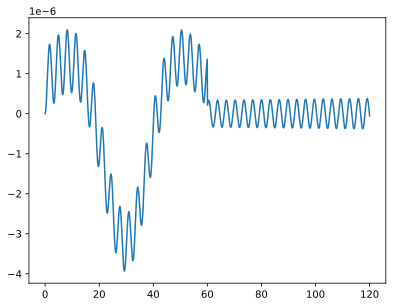

In [111]:
plt.plot(times, np.real(c2_numeric)-np.real(amplitudes[:, 2]))

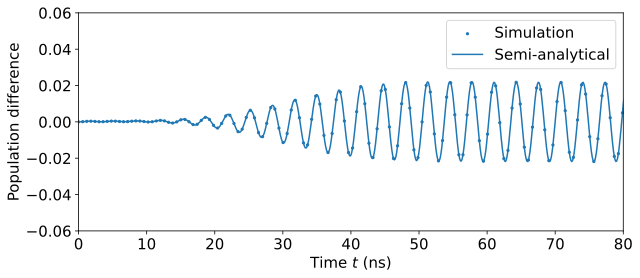

In [112]:
fig, ax = plt.subplots(figsize=(9,4))

ax.scatter(times[::5], (np.real(amplitudes[:, 2][::5])-np.real(ampth_decoupled_square[:, 2][::5])), s=5, label='Simulation')
ax.plot(times, np.real(c2_numeric)-np.real(ampth_decoupled_square[:, 2]), label='Semi-analytical')
ax.set_xlim([0, tg+20])
ax.set_ylim([-0.06, 0.06])
ax.set_xlabel('Time $t$ (ns)',fontsize=15)
ax.set_ylabel('Population difference', fontsize=15)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.legend(fontsize=15)

fig.tight_layout()
# fig.savefig('./figures/pa_note/fig14.eps')

### Polar

In [113]:
complex_num = amplitudes[:, 1]

In [114]:
complex_num[0]

0.5773502691896258j

In [115]:
radii = np.abs(complex_num) 
angles = np.angle(complex_num)

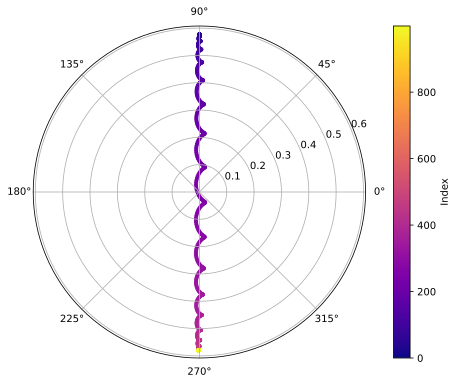

In [116]:
indices = np.arange(len(complex_num))

# Plot
plt.figure(figsize=(10, 6))
ax = plt.subplot(111, polar=True)

# Use index to define color gradient
sc = ax.scatter(angles, radii, c=indices, cmap='plasma', s=10)
plt.colorbar(sc, ax=ax, label='Index')
plt.show()

In [117]:
ampth_decoupled_square[:, 1].shape

(1000,)

In [118]:
complex_num_2 = np.zeros(len(times), dtype=complex)
column = ampth_decoupled_square[:, 1]
for idx, t in enumerate(times):
    complex_num_2[idx] = column[idx] + 0.005*np.exp(1j*Delta_2*t)

radii = np.abs(complex_num_2) 
angles = np.angle(complex_num_2)

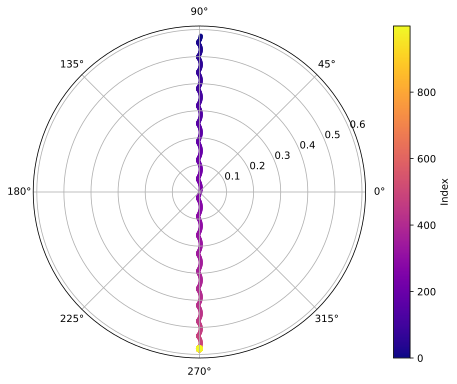

In [119]:
indices = np.arange(len(complex_num_2))

# Plot
plt.figure(figsize=(10, 6))
ax = plt.subplot(111, polar=True)

# Use index to define color gradient
sc = ax.scatter(angles, radii, c=indices, cmap='plasma', s=10)
plt.colorbar(sc, ax=ax, label='Index')
plt.show()

---